In [1]:
%load_ext autoreload
%autoreload 2

import torch
# torch.set_default_dtype(torch.float64)
from typing import Optional

from agent.components.commons import ServiceFeatureMapping, ServiceType
from notebooks.create_deepGP import prepare_chained_data, get_prepared_metrics_df, DynamicServiceChain

converted_df = get_prepared_metrics_df("../statics/agent_experience/metrics_ICSOC_candidate_solutions_20_100_25.csv")

QR_MAP = ServiceFeatureMapping(ServiceType.QR, [0, 1])
CV_MAP = ServiceFeatureMapping(ServiceType.CV, [2, 3, 4])
PC_MAP = ServiceFeatureMapping(ServiceType.PC, [5, 6])

repetitions = 2
chain_definition = ([QR_MAP] * repetitions) #+ ([CV_MAP] * repetitions) + ([PC_MAP] * repetitions))

train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, chain_definition, test_size=0.2)

In [2]:
def get_training_chunks(num_services, granularity):
    if granularity is None:
        return [list(range(num_services))]
    # Create chunks of size 'granularity'
    return [list(range(i, min(i + granularity, num_services)))
            for i in range(0, num_services, granularity)]


In [3]:
def run_training(train_loader, epochs=800, granularity: Optional[int] = None):
    model = DynamicServiceChain(chain_definition)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

    mlls = [
        gpytorch.mlls.VariationalELBO(model.likelihoods[i], model.gp_layers[i], num_data=len(train_loader.dataset))
        for i in range(len(chain_definition))
    ]

    # Example: granularity=2, num_services=6
    # chunks = [[0, 1], [2, 3], [4, 5]]
    # boundaries = [2, 4] (Indices where we cut the gradient)

    chunks = get_training_chunks(len(chain_definition), granularity)
    boundaries = [chunk[0] for chunk in chunks if chunk[0] != 0]

    print(f"Starting training with granularity={granularity}. Chunks: {chunks}")

    model.train()
    for epoch in range(epochs):
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()

            # 1. Forward pass tells the model where to break the chain
            distributions = model(x_batch, boundary_indices=boundaries)

            # 2. Backward passes for each chunk
            for chunk_indices in chunks:
                # This loss ONLY sees the graph for its specific chunk
                loss = sum([-mlls[i](distributions[i], y_batch[:, i]) for i in chunk_indices])

                # TODO: verify if this makes a difference
                # Since chunks are detached from each other, they don't share paths.
                # You likely don't even need retain_graph=True now!
                loss.backward(retain_graph=True)

            optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")
        if epoch % 50 == 0:
            for i, likelihood in enumerate(model.likelihoods):
                print(f"Noise: {likelihood.noise.item():.4f}")

    for i, gp_layer in enumerate(model.gp_layers):
        print(gp_layer.covar_module.base_kernel.lengthscale)

    return model, boundaries


In [4]:
import torch
import gpytorch


def evaluate_model_performance(dgp_model, test_x, test_y, boundaries, num_mc=100):
    """
    Evaluates a Deep GP chain of arbitrary length.

    Args:
        dgp_model: The DynamicServiceChain instance.
        test_x: Test features tensor.
        test_y: Ground truth targets tensor.
        num_mc: Number of Monte Carlo simulations.
    """
    dgp_model.eval()
    all_samples = []
    num_services = len(dgp_model.configs)

    with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
        for _ in range(num_mc):
            # 1. Dynamically capture all output distributions
            distributions = dgp_model(test_x, boundary_indices=boundaries)

            # 2. Sample from each distribution and stack
            samples = [dist.sample() for dist in distributions]
            s = torch.stack(samples, dim=-1)
            all_samples.append(s)

        # Shape: (num_mc, num_test_samples, num_services)
        combined_samples = torch.stack(all_samples, dim=0).cpu().numpy()

    # --- MODEL VALIDATION ---
    # Get the mean prediction for each service across MC samples
    predicted_means = combined_samples.mean(axis=0)

    # Convert ground truth to numpy
    actual_y = test_y.cpu().numpy()

    print(f"\n--- Model Evaluation ({num_services} Services) ---")

    # 3. Calculate Error dynamically using the names in the model config
    for i, config in enumerate(dgp_model.configs):
        # Use the name or service_type from the config
        # name = config.name if config.name else config.service_type.value

        rmse = np.sqrt(np.mean((predicted_means[:, i] - actual_y[:, i]) ** 2))
        print(f"Stage {i} [{config.service_type.value}] RMSE: {rmse:.4f}")

    return combined_samples

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def draw_distribution(combined_samples, chain_definition):
    # 1. Calculate the mean and std for EACH test case across simulations
    # combined_samples shape: (num_mc, num_test_samples, num_services)
    means_per_config = combined_samples.mean(axis=0)  # Shape: (N_test, N_services)
    stds_per_config = combined_samples.std(axis=0)  # Shape: (N_test, N_services)

    # 2. Average across all test configurations to get the global chain profile
    global_means = means_per_config.mean(axis=0)  # Shape: (N_services,)
    global_stds = stds_per_config.mean(axis=0)  # Shape: (N_services,)

    # Extract service names for the X-axis labels
    stages = range(len(chain_definition))

    plt.figure(figsize=(12, 6))

    # 3. Plot the Global Staircase
    # fmt='-s' connects the dots to show the throughput "decay" or bottlenecking
    plt.errorbar(stages, global_means, yerr=global_stds, fmt='-s', capsize=10,
                 color='navy', ecolor='red', elinewidth=3, markersize=8,
                 label='Average Chain Performance')

    # 4. Annotate the Average Sigma for each stage

    for i, stage in enumerate(stages):
        plt.text(i + 0.05, global_means[i], f'Avg σ = {global_stds[i]:.3f}',
                 va='bottom', fontweight='bold', color='red', fontsize=11)
    # for i, stage_name in enumerate(stages):
    #     plt.text(i + 0.1, global_means[i], f'σ={global_stds[i]:.3f}',
    #              va='bottom', fontweight='bold', color='red', fontsize=9)

    plt.title(f"Global Throughput Bottleneck ({len(stages)} Stages)")
    plt.ylabel("Average Scaled Throughput (0-1)")
    plt.xlabel("Service Pipeline Sequence")

    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')

    # 5. Shaded area showing Hardware Diversity (Best vs Worst config)
    plt.fill_between(stages,
                     means_per_config.min(axis=0),
                     means_per_config.max(axis=0),
                     color='gray', alpha=0.1, label='Hardware Spread')

    plt.tight_layout()
    plt.show()

In [6]:
model_single, boundaries_single = run_training(train_loader, epochs=110, granularity=1)
torch.save(model_single.state_dict(), 'service_chain_model_single.pth')

Starting training with granularity=1. Chunks: [[0], [1]]


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 0 | Loss: 0.8075
Noise: 0.6694
Noise: 0.6384
Epoch 10 | Loss: -0.2398
Epoch 20 | Loss: -1.0272
Epoch 30 | Loss: -1.2995
Epoch 40 | Loss: -1.5286
Epoch 50 | Loss: -1.0588
Noise: 0.0027
Noise: 0.0039
Epoch 60 | Loss: -1.3829
Epoch 70 | Loss: -1.5714
Epoch 80 | Loss: -1.4026
Epoch 90 | Loss: -1.4075
Epoch 100 | Loss: -1.3228
Noise: 0.0022
Noise: 0.0037
tensor([[0.3741, 0.1806]], grad_fn=<SoftplusBackward0>)
tensor([[1.1927, 0.7930, 0.6862]], grad_fn=<SoftplusBackward0>)



--- Model Evaluation (2 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0434
Stage 1 [elastic-workbench-qr-detector] RMSE: 0.0554


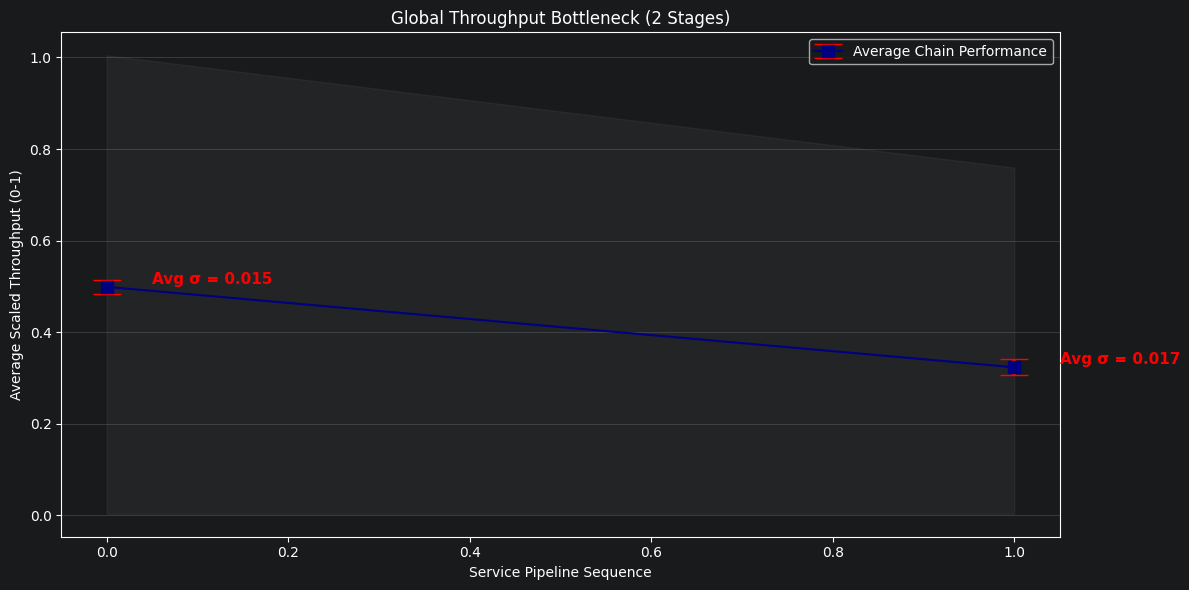

In [7]:
# train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, chain_definition, test_size=0.2)

# combined_samples_global = evaluate_model_performance(model_global, test_x, test_y, boundaries_global, 100)
# draw_distribution(combined_samples_global, chain_definition)

combined_samples_single = evaluate_model_performance(model_single, test_x, test_y, boundaries_single, 100)
draw_distribution(combined_samples_single, chain_definition)

In [8]:
# def plot_residual_divergence(samples_none, samples_one, test_y):
#     # Calculate Error (Predicted Mean - Actual)
#     err_none = np.abs(samples_none.mean(axis=0) - test_y.cpu().numpy())
#     err_one = np.abs(samples_one.mean(axis=0) - test_y.cpu().numpy())
#
#     plt.figure(figsize=(10, 5))
#     plt.plot(err_none.mean(axis=0), label='Global Error', color='blue', marker='o')
#     plt.plot(err_one.mean(axis=0), label='Independent Error', color='green', marker='x')
#
#     plt.title("Error Propagation: Global vs Independent")
#     plt.xlabel("Chain Stage")
#     plt.ylabel("Mean Absolute Error")
#     plt.legend()
#     plt.show()
#
# plot_residual_divergence(combined_samples_global, combined_samples_single, test_y)

In [12]:
import torch
import copy


def expand_selected_services(model_single: DynamicServiceChain, composite_model: DynamicServiceChain):
    """
    Knowledge Transfer from [QR, CV, PC] to [QR, CV, CV, PC, PC].
    - QR (Stage 0): Direct Copy (2D)
    - CV (Stage 1): Direct Copy (3D - already 3D in model_single)
    - CV (Stage 2): Mirror Injection (3D -> 3D)
    - PC (Stage 3): Direct Copy (3D)
    - PC (Stage 4): Mirror Injection (3D -> 3D)
    """

    # Mapping the target indices to the expert indices in model_single
    # Target: 0 (QR), 1 (CV), 2 (CV), 3 (PC), 4 (PC)
    # Source: 0 (QR), 1 (CV), 1 (CV), 2 (PC), 2 (PC)
    mapping = [0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

    with torch.no_grad():
        for i, src_idx in enumerate(mapping):
            expert_gp = model_single.gp_layers[src_idx]
            target_gp = composite_model.gp_layers[i]

            # Case 1: Shapes match (Direct weight transfer)
            # This happens for Stage 0 (QR) and the first instances of CV and PC
            if expert_gp.variational_strategy.inducing_points.shape == target_gp.variational_strategy.inducing_points.shape:
                target_gp.load_state_dict(copy.deepcopy(expert_gp.state_dict()))
                composite_model.likelihoods[i].load_state_dict(
                    copy.deepcopy(model_single.likelihoods[src_idx].state_dict()))

            # Case 2: Size Mismatch (Injection needed)
            # This would happen if you were moving a 2D expert into a 3D slot
            else:
                expert_state = expert_gp.state_dict()
                target_state = target_gp.state_dict()

                for name, param in expert_state.items():
                    if 'inducing_points' in name:
                        # Inject the first column (Feature 0) into the new 3rd column
                        col_to_inject = param[:, 0:1]
                        target_state[name] = torch.cat([param, col_to_inject], dim=1)
                    elif 'raw_lengthscale' in name:
                        val_to_inject = param[:, 0:1]
                        target_state[name] = torch.cat([param, val_to_inject], dim=1)
                    else:
                        target_state[name] = param

                target_gp.load_state_dict(target_state)
                composite_model.likelihoods[i].load_state_dict(
                    copy.deepcopy(model_single.likelihoods[src_idx].state_dict()))

    print("Success: Selected services duplicated into the new chain.")


# --- Usage ---
amplified_chain = [QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP, QR_MAP]
composite_model = DynamicServiceChain(amplified_chain)
expand_selected_services(model_single, composite_model)



Success: Selected services duplicated into the new chain.



--- Model Evaluation (10 Services) ---
Stage 0 [elastic-workbench-qr-detector] RMSE: 0.0356
Stage 1 [elastic-workbench-qr-detector] RMSE: 0.0573
Stage 2 [elastic-workbench-qr-detector] RMSE: 0.2624
Stage 3 [elastic-workbench-qr-detector] RMSE: 0.3196
Stage 4 [elastic-workbench-qr-detector] RMSE: 0.3070
Stage 5 [elastic-workbench-qr-detector] RMSE: 0.2688
Stage 6 [elastic-workbench-qr-detector] RMSE: 0.2806
Stage 7 [elastic-workbench-qr-detector] RMSE: 0.2502
Stage 8 [elastic-workbench-qr-detector] RMSE: 0.2540
Stage 9 [elastic-workbench-qr-detector] RMSE: 0.2411


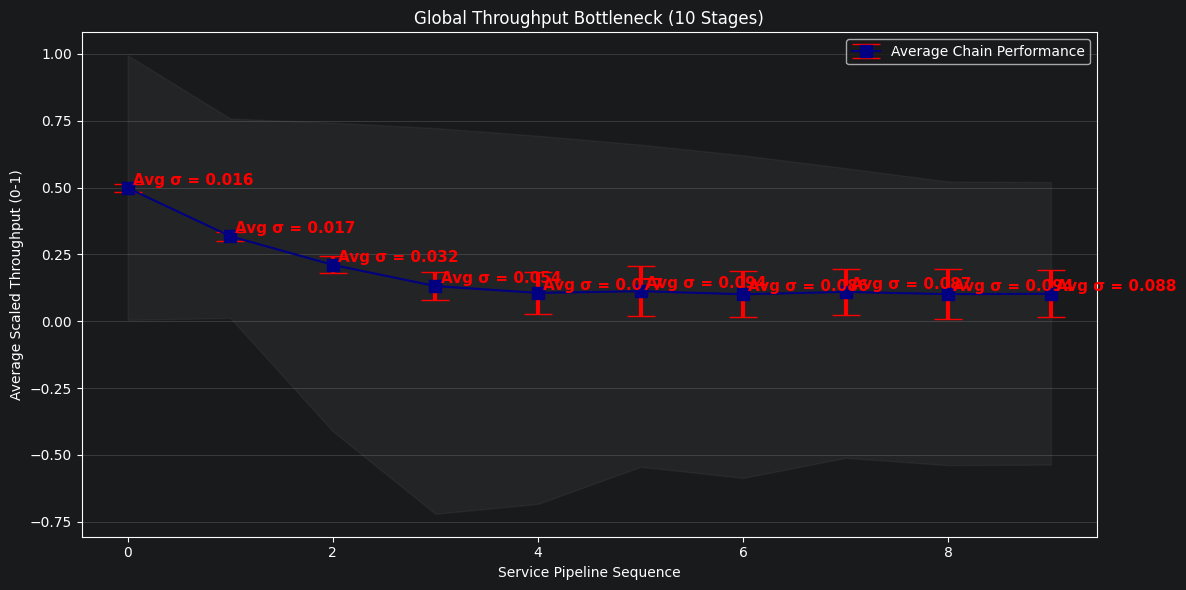

In [13]:
train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, amplified_chain, test_size=0.2)

combined_samples_composite = evaluate_model_performance(composite_model, test_x, test_y, boundaries_single, 100)
draw_distribution(combined_samples_composite, amplified_chain)